<a href="https://colab.research.google.com/github/ahaddd-ship-it/24-ahad-assignment2/blob/main/dav2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original dataset shape: (100, 6)
Sentiment
positive    48
neutral     34
negative    18
Name: count, dtype: int64
Training samples: 80, Test samples: 20

=== Naïve Bayes Performance ===
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
     Neutral       1.00      0.14      0.25         7
    Positive       0.47      1.00      0.64         9

    accuracy                           0.50        20
   macro avg       0.49      0.38      0.30        20
weighted avg       0.56      0.50      0.38        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


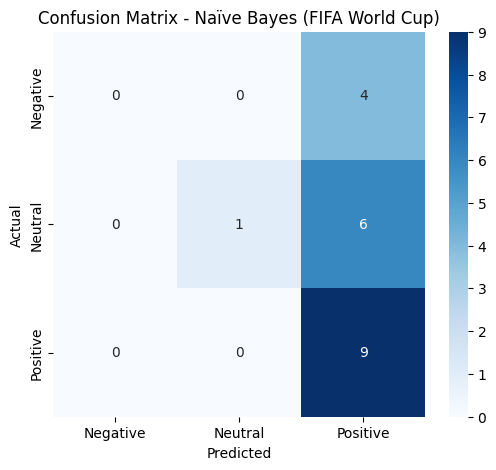


=== Logistic Regression Performance ===
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
     Neutral       0.25      0.29      0.27         7
    Positive       0.50      0.67      0.57         9

    accuracy                           0.40        20
   macro avg       0.25      0.32      0.28        20
weighted avg       0.31      0.40      0.35        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


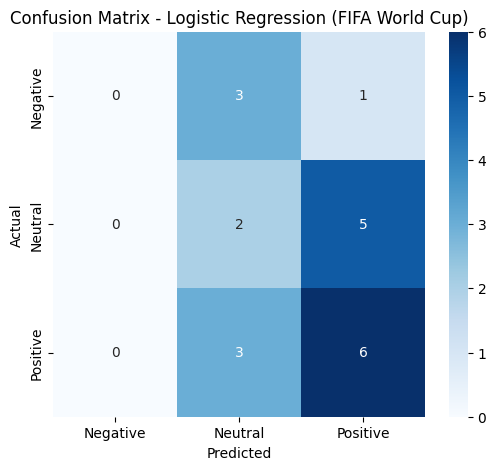


=== SVM Performance ===
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
     Neutral       0.20      0.29      0.24         7
    Positive       0.50      0.56      0.53         9

    accuracy                           0.35        20
   macro avg       0.23      0.28      0.25        20
weighted avg       0.30      0.35      0.32        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


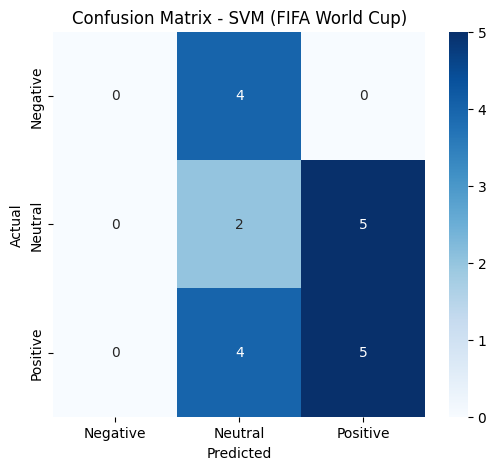


Final Model Comparison on FIFA Tweets:


,Precision,Recall,Accuracy
Naïve Bayes,0.5632,0.50,0.50
Logistic Regression,0.3125,0.40,0.40
SVM,0.2950,0.35,0.35


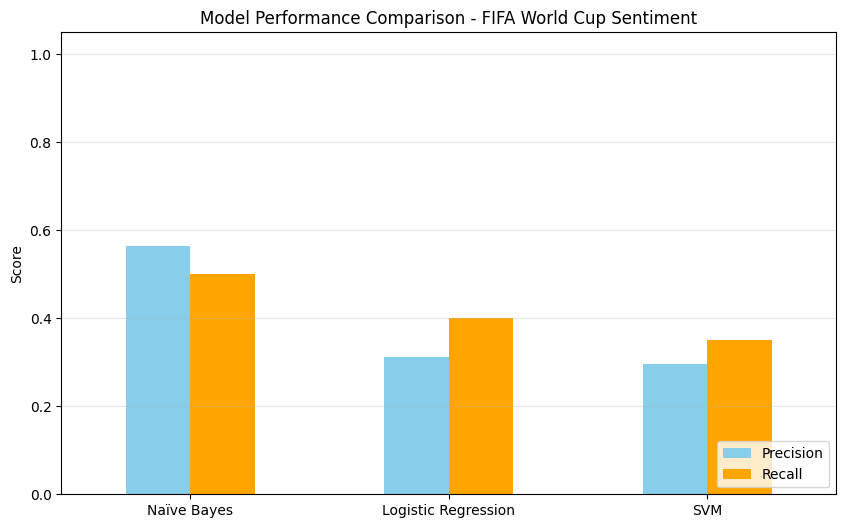

In [2]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report, confusion_matrix

# Create directory for results if it doesn't exist
os.makedirs('results', exist_ok=True)

# ==================== 1. LOAD DATA ====================
# Using the path provided in the environment context
df = pd.read_csv('/content/fifa_world_cup_2022_tweets.csv')

print("Original dataset shape:", df.shape)
print(df['Sentiment'].value_counts())

# Select 100 tweets related to FIFA
df_fifa = df.sample(n=100, random_state=42).copy()

# Map sentiment to numeric labels - adjusted to lowercase to match standard_output
label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df_fifa['label'] = df_fifa['Sentiment'].map(label_map)

# ==================== 2. TEXT CLEANING ====================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

df_fifa['clean_text'] = df_fifa['Tweet'].apply(clean_text)

# ==================== 3. TRAIN-TEST SPLIT (80/20) ====================
X = df_fifa['clean_text']
y = df_fifa['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# ==================== 4. TF-IDF VECTORIZATION ====================
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ==================== 5. TRAIN THREE CLASSIFIERS ====================
models = {
    'Naïve Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM': SVC(kernel='linear', probability=True, class_weight='balanced')
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {'Precision': round(precision, 4),
                     'Recall': round(recall, 4),
                     'Accuracy': round(accuracy, 4)}

    print(f"\n=== {name} Performance ===")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix - {name} (FIFA World Cup)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# ==================== 6. MODEL COMPARISON ====================
results_df = pd.DataFrame(results).T
print("\nFinal Model Comparison on FIFA Tweets:")
display(results_df)

# Visualization
results_df[['Precision', 'Recall']].plot(kind='bar', figsize=(10,6), color=['skyblue', 'orange'])
plt.title('Model Performance Comparison - FIFA World Cup Sentiment')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Save results
results_df.to_csv('results/fifa_model_comparison.csv')